\textbf{Opgave 1 (vægt: 35\%).}
Et omrejsende cirkus er i færd med at planlægge den næste
sæson, bl.a.\ med henblik på at bestemme, hvilke byer der skal
have besøg af cirkuset.

Vi betragter her et bestemt geografisk område med 15 byer,
som man ønsker at tage i betragtning. Disse er hver især
repræsenteret ved deres centrum med de koordinater $(x,y)$,
som fremgår af den følgende tabel. Byernes beliggenheder er
vist i Figur~1.

\[
\begin{array}{c|ccccccccccccccc}
\text{By } j
&1&2&3&4&5&6&7&8&9&10&11&12&13&14&15\\
\hline
x_j
&2.5&3.7&1.9&3.1&4.5&6.2&7.2&7.7&2.2&2.8&5.1&6.5&5.4&4.1&4.5\\
y_j
&7.5&7.7&4.7&3.5&4.5&2.1&2.8&1.4&3.6&4.2&6.1&5.3&5.0&2.7&3.5
\end{array}
\]

## Spm. 1)
This is a set covering problem. We want to find the minimum number of cities to visit such that all cities are covered within a distance of 2 and 3 units respectively. In this case both the set S is the cities and the subsets famliy F is also the cities as the circus must be located in a city.

Solution for L = 2

Status: Optimal
Objective value: 4.0
Subset (2.5, 7.5) is included in the solution with cost 1
Subset (3.1, 3.5) is included in the solution with cost 1
Subset (7.7, 1.4) is included in the solution with cost 1
Subset (6.5, 5.3) is included in the solution with cost 1


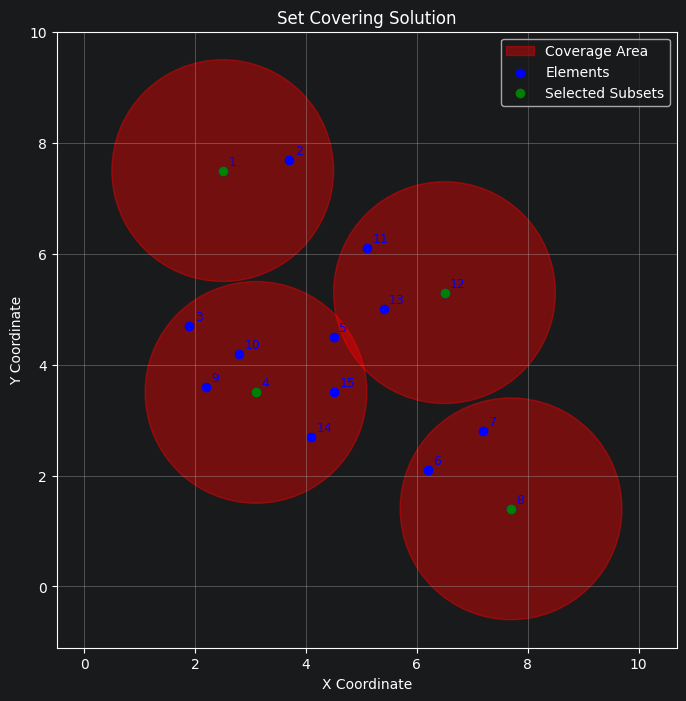

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Set Covering Solution'}, xlabel='X Coordinate', ylabel='Y Coordinate'>)

In [1]:
from modeller.set_covering_problem import set_covering_problem
import numpy as np
from itertools import product
x = "2.5 3.7 1.9 3.1 4.5 6.2 7.2 7.7 2.2 2.8 5.1 6.5 5.4 4.1 4.5".split(" ")
y = "7.5 7.7 4.7 3.5 4.5 2.1 2.8 1.4 3.6 4.2 6.1 5.3 5.0 2.7 3.5".split(" ")
x = [float(i) for i in x]
y = [float(i) for i in y]

city_coordinates = list(zip(x,y))
possible_coordinates = city_coordinates
city_range = range(len(x))

# Set is covered if distance is less than L
L = 2
# Shape of (|M|, |F|)
adj_matrix = np.zeros((len(city_coordinates), len(possible_coordinates)))

def dist(coord1, coord2):
    return ((coord1[0] - coord2[0]) ** 2 + (coord1[1] - coord2[1]) ** 2) ** 0.5

# Fill adj-matrix
for i, c_coord in enumerate(city_coordinates):
    for j, p_coord in enumerate(possible_coordinates):
        if dist(c_coord, p_coord) <= L:
            adj_matrix[i][j] = 1
        else:
            adj_matrix[i][j] = 0

# Equally weighted
weights = [1] * len(city_coordinates)
# Equal costs
costs = [1] * len(possible_coordinates)
print("Solution for L = 2\n")
SCPL2 = set_covering_problem(adj_matrix, weights, costs, possible_coordinates)
SCPL2.solve_and_print()
SCPL2.plot_solution(city_coordinates, coverage_radius = L)






For $L=2$ we find that we need to visit 4 cities at minimum. The cities are 1, 4, 8 and 12. We now proceed to $L=3$.

Solution for L = 3

Status: Optimal
Objective value: 3.0
Subset (3.7, 7.7) is included in the solution with cost 1
Subset (7.7, 1.4) is included in the solution with cost 1
Subset (4.5, 3.5) is included in the solution with cost 1


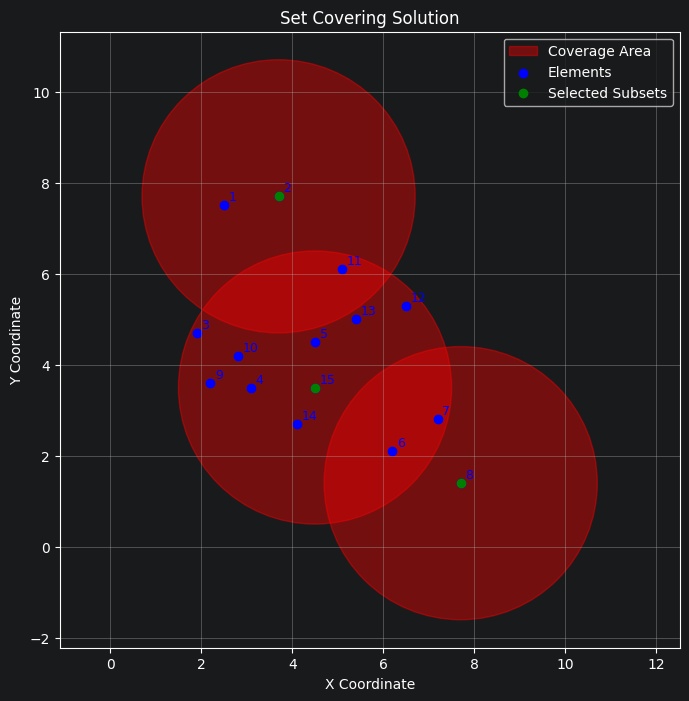

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Set Covering Solution'}, xlabel='X Coordinate', ylabel='Y Coordinate'>)

In [2]:
L = 3
adj_matrix = np.zeros((len(city_coordinates), len(possible_coordinates)))
# Fill adj-matrix
for i, c_coord in enumerate(city_coordinates):
    for j, p_coord in enumerate(possible_coordinates):
        if dist(c_coord, p_coord) <= L:
            adj_matrix[i][j] = 1
        else:
            adj_matrix[i][j] = 0

# Equally weighted
weights = [1] * len(city_coordinates)
# Equal costs
costs = [1] * len(possible_coordinates)
print("Solution for L = 3\n")
SCPL3 = set_covering_problem(adj_matrix, weights, costs, possible_coordinates)
SCPL3.solve_and_print()
SCPL3.plot_solution(city_coordinates, coverage_radius = L)

For $L=3$ we find that we need to visit 3 cities at minimum. The cities are 2, 8 and 15

## Spm. 2)
To make it more accessible for bigger cities 1-8, we can assign a weight of 2 such that each city must be contrained to be covered at least twice.

Solution for L = 2

Status: Optimal
Objective value: 7.0
Subset (2.5, 7.5) is included in the solution with cost 1
Subset (3.7, 7.7) is included in the solution with cost 1
Subset (1.9, 4.7) is included in the solution with cost 1
Subset (3.1, 3.5) is included in the solution with cost 1
Subset (6.2, 2.1) is included in the solution with cost 1
Subset (7.2, 2.8) is included in the solution with cost 1
Subset (5.1, 6.1) is included in the solution with cost 1


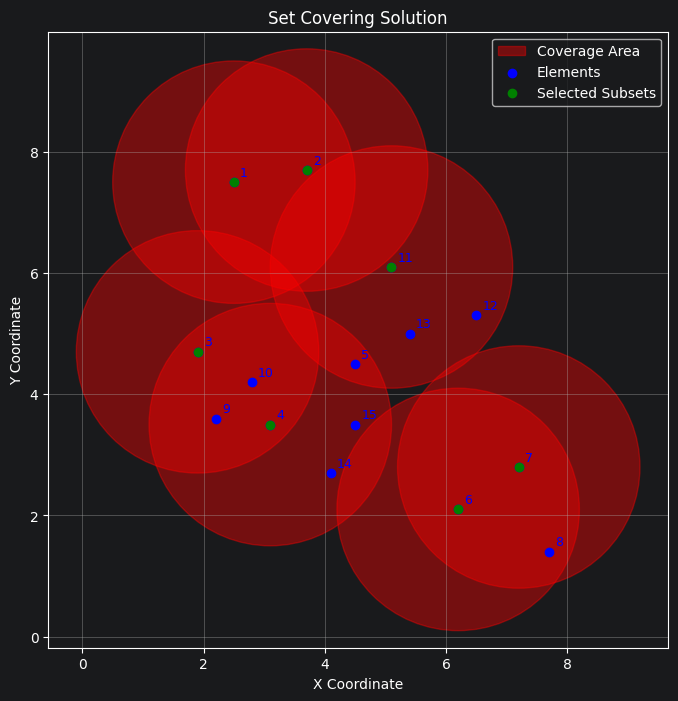

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Set Covering Solution'}, xlabel='X Coordinate', ylabel='Y Coordinate'>)

In [3]:
L = 2
adj_matrix = np.zeros((len(city_coordinates), len(possible_coordinates)))
# Fill adj-matrix
for i, c_coord in enumerate(city_coordinates):
    for j, p_coord in enumerate(possible_coordinates):
        if dist(c_coord, p_coord) <= L:
            adj_matrix[i][j] = 1
        else:
            adj_matrix[i][j] = 0

# Equally weighted
weights = [1] * len(city_coordinates)
weights = [2  if i < 8 else 1 for i in range(len(weights))]
print("Solution for L = 2\n")
# Equal costs
costs = [1] * len(possible_coordinates)
SCP_weighted_L2 = set_covering_problem(adj_matrix, weights, costs, possible_coordinates)
SCP_weighted_L2.solve_and_print()
SCP_weighted_L2.plot_solution(city_coordinates, coverage_radius= L)

We find that we need to visit 7 cities at minimum. We compute the same for $L=3$.

Solution for L = 2

Status: Optimal
Objective value: 6.0
Subset (2.5, 7.5) is included in the solution with cost 1
Subset (3.7, 7.7) is included in the solution with cost 1
Subset (4.5, 4.5) is included in the solution with cost 1
Subset (7.2, 2.8) is included in the solution with cost 1
Subset (7.7, 1.4) is included in the solution with cost 1
Subset (4.5, 3.5) is included in the solution with cost 1


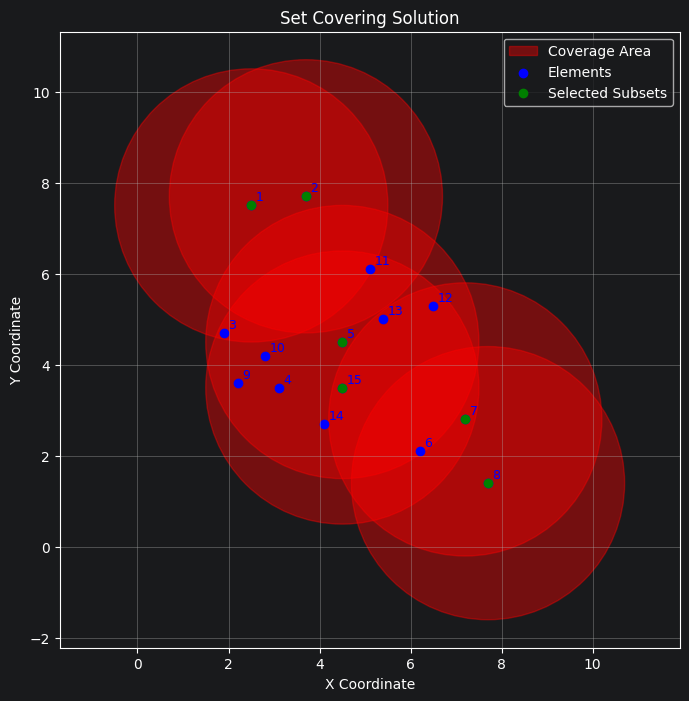

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Set Covering Solution'}, xlabel='X Coordinate', ylabel='Y Coordinate'>)

In [4]:
L = 3
adj_matrix = np.zeros((len(city_coordinates), len(possible_coordinates)))
# Fill adj-matrix
for i, c_coord in enumerate(city_coordinates):
    for j, p_coord in enumerate(possible_coordinates):
        if dist(c_coord, p_coord) <= L:
            adj_matrix[i][j] = 1
        else:
            adj_matrix[i][j] = 0

# Equally weighted
weights = [1] * len(city_coordinates)
weights = [2  if i < 8 else 1 for i in range(len(weights))]
print("Solution for L = 2\n")
# Equal costs
costs = [1] * len(possible_coordinates)
SCP_weighted_L3 = set_covering_problem(adj_matrix, weights, costs, possible_coordinates)
SCP_weighted_L3.solve_and_print()
SCP_weighted_L3.plot_solution(city_coordinates, coverage_radius= L)

We find that we need to visit 6 cities at minimum. We find that the solutions are changed such that we must visit more cities than before if we want double coverage for the large cities. Increasing the coverage radius from 2 to 3 only reduces the numbers of cities we need to visit by 1.

## Spm. 3)
We can add this constraint by requiring that the sum of the variables corresponding to cites 1,5 and 8 must be at most 2, since they are binary 0 or 1, this means that at most 2 of the 3 cities can be visited.

Status: Optimal
Objective value: 6.0
Subset (3.7, 7.7) is included in the solution with cost 1
Subset (4.5, 4.5) is included in the solution with cost 1
Subset (6.2, 2.1) is included in the solution with cost 1
Subset (7.2, 2.8) is included in the solution with cost 1
Subset (5.1, 6.1) is included in the solution with cost 1
Subset (4.5, 3.5) is included in the solution with cost 1


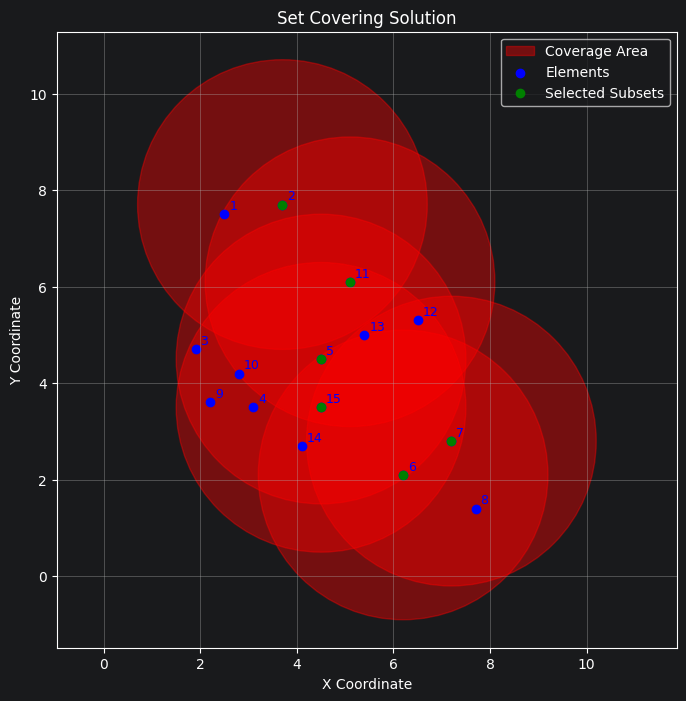

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Set Covering Solution'}, xlabel='X Coordinate', ylabel='Y Coordinate'>)

In [5]:
import pulp as PLP
SCP_weighted_L3.model.constraints.clear()
SCP_weighted_L3.model += PLP.lpSum(SCP_weighted_L3.delta[j] for j in range(SCP_weighted_L3.n) if j in [0,4,7]) <= 2, "Max2"
SCP_weighted_L3.solve_and_print()
SCP_weighted_L3.plot_solution(city_coordinates, coverage_radius= L)


## Spm. 4)
We can add the constraint that if 1 and 5 are both visited, then 8 must also be visited by adding the following constraints:
$$\delta_1 + \delta_5 \leq 1 + \delta_8$$
Since if both 1 and 5 are visited, then the left hand side is 2, which means that $\delta_8$ must be 1 to satisfy the constraint. If either 1 or 5 is not visited, then the left hand side is at most 1, which means that $\delta_8$ can be either 0 or 1 without violating the constraint.

# Opgave 2

# Opgave 3

In [6]:
from modeller.clustering_from_shortest_path import clustering_from_shortest_path
nodes = list(range(13))
group_sizes = [3,4,5]
edges = [(i, i + j) for i in nodes for j in group_sizes if i + j < len(nodes)]
def cost(edges):
    F = "0.0 1.2 1.4 2.1 2.3 2.9 3.5 4.1 4.9 5.4 5.7 6.2 6.8".split(" ")
    F = [float(x) for x in F]

    return [F[j] - F[i + 1] for i, j in edges]

CFSP = clustering_from_shortest_path(nodes, edges, cost)
CFSP.solve_and_print()




Status: Optimal
Objective value: 4.199999999999999
Edge (0, 4) is included in the solution with cost 1.1
This corresponds to the group [1, 2, 3, 4]

Edge (4, 7) is included in the solution with cost 1.2
This corresponds to the group [5, 6, 7]

Edge (7, 12) is included in the solution with cost 1.9
This corresponds to the group [8, 9, 10, 11, 12]



In [10]:
CFSP = clustering_from_shortest_path(nodes, edges, cost)
#create new binary variables indexed by tuple edges
CFSP.x = PLP.LpVariable.dicts("x", CFSP.edges, lowBound=0, upBound=1, cat=PLP.LpBinary)
# create new cont. variable F (continuous)
F = PLP.LpVariable("F", lowBound=None, cat=PLP.LpContinuous)
# start a fresh model
CFSP.model = PLP.LpProblem("Clustering_from_shortest_path", PLP.LpMinimize)
# New objective
CFSP.model += F, "Objective"
# add cost bound constraint: cost(e) * x[e] <= F
costs = cost(CFSP.edges)
for k, e in enumerate(CFSP.edges):
    CFSP.model += CFSP.x[e] * costs[k] <= F, f"Cost_Bound{k}"
CFSP.solve_and_print()

Status: Optimal
Objective value: 1.3
Edge (0, 3) is included in the solution with cost 0.9
This corresponds to the group [1, 2, 3]

Edge (3, 6) is included in the solution with cost 1.2
This corresponds to the group [4, 5, 6]

Edge (6, 9) is included in the solution with cost 1.3
This corresponds to the group [7, 8, 9]

Edge (9, 12) is included in the solution with cost 1.1
This corresponds to the group [10, 11, 12]

